# 多臂老虎机：ε-greedy 与增量样本均值

In [2]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

Matplotlib is building the font cache; this may take a moment.


In [ ]:
class Bandit:
    """10 臂老虎机环境。"""

    def __init__(self, arms: int = 10, seed=None):
        if seed is not None:
            np.random.seed(seed)
        self.rates = np.random.rand(arms)  # 每台机器的胜率

    def play(self, arm: int) -> int:
        rate = self.rates[arm]
        return 1 if rate > np.random.rand() else 0

    def display(self) -> None:
        """输出各臂的真实胜率。"""
        print("各臂胜率:", self.rates)


class Agent:
    """ε-greedy 策略的智能体。"""

    def __init__(self, epsilon: float, action_size: int = 10):
        self.epsilon = epsilon
        self.Qs = np.zeros(action_size)
        self.ns = np.zeros(action_size)

    def update(self, action: int, reward: float) -> None:
        self.ns[action] += 1
        self.Qs[action] += (reward - self.Qs[action]) / self.ns[action]

    def get_action(self) -> int:
        if np.random.rand() < self.epsilon:
            return np.random.randint(0, len(self.Qs))
        # np.argmax(self.Qs) 可以得到数组 self.Qs 中最大元素的索引, 即贪心策略下
        # 选择胜率最高的臂
        return int(np.argmax(self.Qs))


In [8]:
bandit = Bandit()
bandit.display()

各臂胜率: [0.77963592 0.02921898 0.0078356  0.74310439 0.33598021 0.78093623
 0.46818531 0.47789201 0.31233249 0.61094006]


In [14]:
steps = 1000
epsilon = 0.1
agent = Agent(epsilon)
total_reward = 0
total_rewards = []
rates = []

for step in range(steps):
    action = agent.get_action()
    reward = bandit.play(action)
    agent.update(action, reward)
    total_reward += reward
    total_rewards.append(total_reward)
    rates.append(total_reward / (step + 1))

print(f"Total reward: {total_reward}")

Total reward: 736


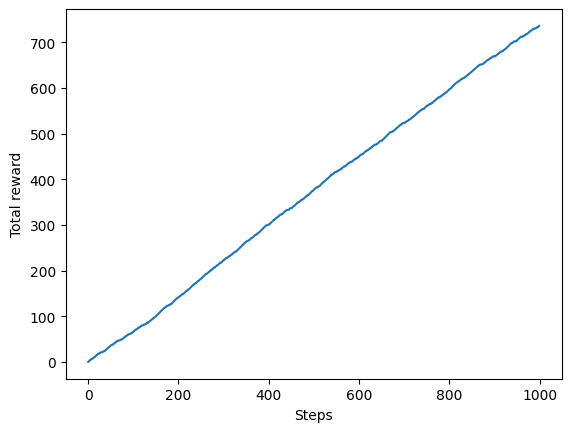

In [15]:
plt.ylabel("Total reward")
plt.xlabel("Steps")
plt.plot(total_rewards)
plt.show()

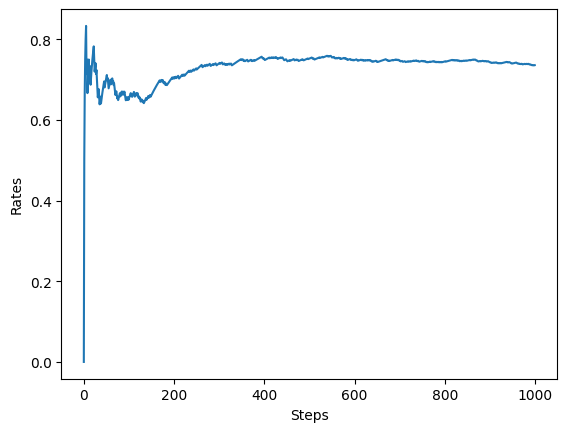

In [16]:
plt.ylabel("Rates")
plt.xlabel("Steps")
plt.plot(rates)
plt.show()

## 200 次实验取平均

In [17]:
runs = 200
steps = 1000
epsilons = [0.01, 0.1, 0.3]
results = {}  # {epsilon: avg_rates}

for epsilon in epsilons:
    all_rates = np.zeros((runs, steps))
    for run in range(runs):
        bandit = Bandit()
        agent = Agent(epsilon)
        total_reward = 0
        rates = []
        for step in range(steps):
            action = agent.get_action()
            reward = bandit.play(action)
            agent.update(action, reward)
            total_reward += reward
            rates.append(total_reward / (step + 1))
        all_rates[run] = rates
    results[epsilon] = np.average(all_rates, axis=0)

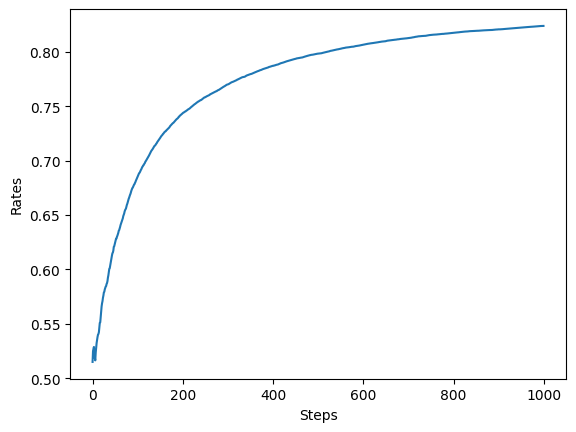

In [18]:
colors = ["tab:blue", "tab:orange", "tab:green"]
for epsilon, color in zip(epsilons, colors):
    plt.plot(results[epsilon], label=f"ε={epsilon}", color=color)
plt.ylabel("Rates")
plt.xlabel("Steps")
plt.legend()
plt.show()